# End-to-End Fraud Detection System

# part 1 Problem framing

In [150]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


df = pd.read_csv("creditcard.csv")

In [151]:
print(df.head())
print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## this dataset is
* A credit card transaction dataset from Europe over two days in September 2013.
* Each row = one transaction.
* Goal = detect fraud (class = 1) vs. normal transactions (class = 0).

## columns
Time (The seconds since the very first transaction in the dataset)
* 0 being first transaction ever recorded in this two-day window. 10 being 10 seconds later
* multiple transactions can happen in same second

V1 -> v28 (“secret summary scores” of a transaction)
* don’t need to know literal means, the model will uses the patterns in these numbers (v1-v28).

Amount (money value of the transaction)

class (0 = normal transaction, 1 = fraud)

In [152]:
print(df['Class'].value_counts())
df.describe()

Class
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [153]:
df.corr()['Class'].sort_values()

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64

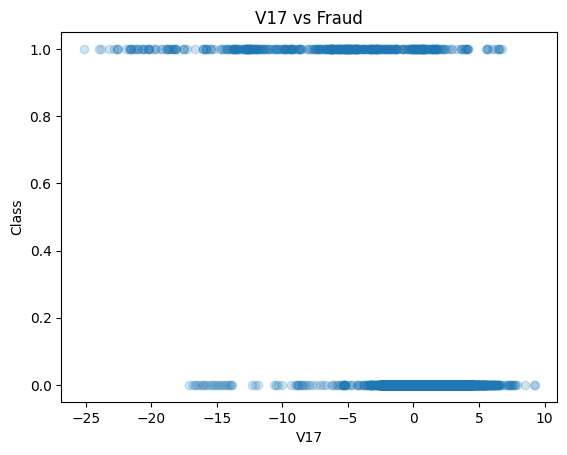

In [154]:
plt.scatter(df['V17'], df['Class'], alpha=0.2)
plt.xlabel("V17")
plt.ylabel("Class")
plt.title("V17 vs Fraud")
plt.show()

## Part 2 Data preprocessing 

train/ test split

In [155]:
X = df.drop("Class", axis=1) # features (inputs)/ transaction details. states our inputs are all the columns except for class
y = df["Class"] # labels (outputs)/ fraud or not fraud
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

analyse class imbalance

In [156]:
y_train.value_counts(normalize=True)

Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

fraud is extremely rare, creating class imbalance

feature scaling

In [157]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

training on dummy classifier

In [158]:
dummy = DummyClassifier(strategy="most_frequent") #Always predicts the majority class
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

accuracy_score(y_test, y_pred_dummy)

0.9982795547909132

Accuracy alone is misleading when classes are highly imbalanced.

# Part 3 logistic regression baseline

logistic regression training

In [159]:
# handle imbalance using class_weight
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]  # probabilities for class 1

Proper evaluation 

In [160]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[55528  1336]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



ROC Curve

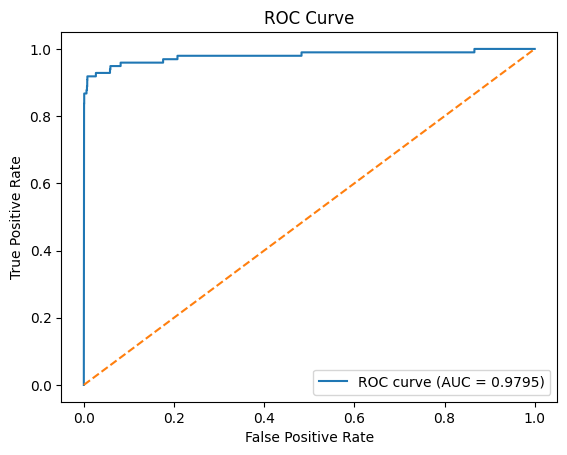

In [161]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Precesion recal curve

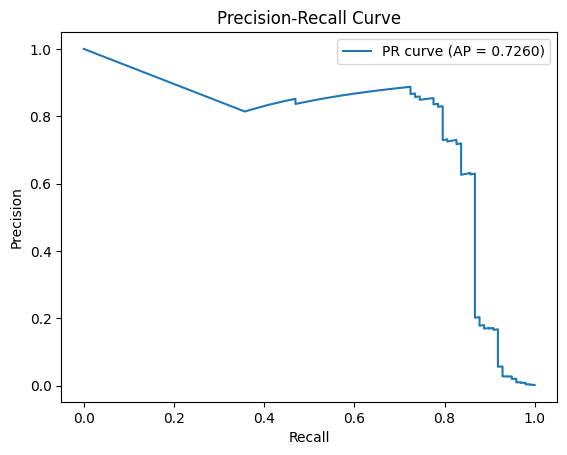

In [162]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"PR curve (AP = {pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## part 4 tree-based models

random forest 

In [163]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

Evaluating 

In [164]:
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, rf_prob))
print("PR-AUC Score:", average_precision_score(y_test, rf_prob))

Random Forest Confusion Matrix:
[[56863     1]
 [   24    74]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.76      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.9622936716892722
PR-AUC Score: 0.8817106461838264


Feature Importance

V14    0.178671
V10    0.111806
V12    0.105139
V4     0.104866
V17    0.089484
V3     0.057374
V16    0.056818
V11    0.056444
V2     0.031804
V7     0.022059
dtype: float64


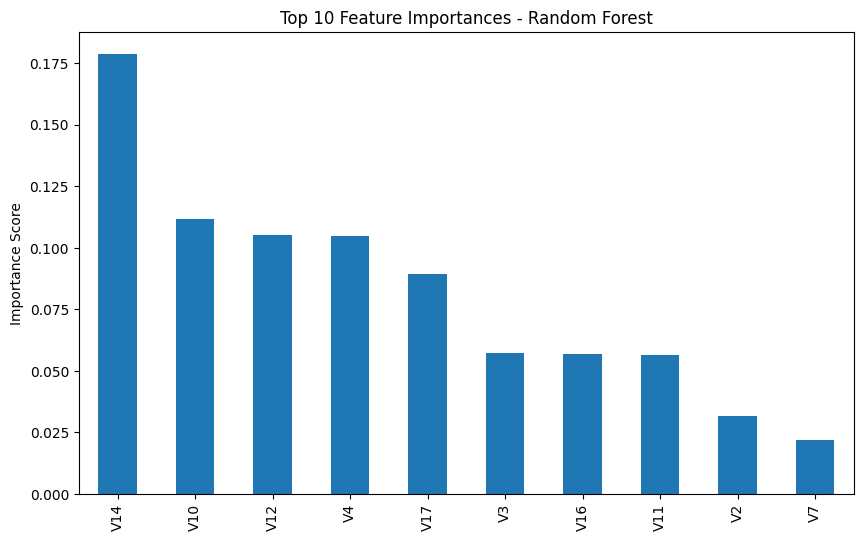

In [165]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))


plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importances - Random Forest")
plt.ylabel("Importance Score")
plt.show()

Final comparison table

In [166]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, rf_prob)
    ]
})

print(comparison)

                 Model   ROC-AUC    PR-AUC
0  Logistic Regression  0.979509  0.725960
1        Random Forest  0.962294  0.881711


# Part 5 Making advanced model with XGBoost

Create and Train

In [167]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    random_state=42,
    eval_metric='logloss'
)


xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

Evaluating XGBoost

In [168]:
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, xgb_prob))
print("PR-AUC Score:", average_precision_score(y_test, xgb_prob))

XGBoost Confusion Matrix:
[[56859     5]
 [   25    73]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.74      0.83        98

    accuracy                           1.00     56962
   macro avg       0.97      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.9853720082574391
PR-AUC Score: 0.8711567939504026


Hyperperameter Tuning 

In [169]:
param_grid = {
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=param_grid,
    scoring='average_precision',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest PR-AUC Score:")
print(grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters:
{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}

Best PR-AUC Score:
0.8550045522527273


best tuned model

In [170]:
best_xgb = grid_search.best_estimator_

best_pred = best_xgb.predict(X_test)
best_prob = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost ROC-AUC:",
      roc_auc_score(y_test, best_prob))

print("Tuned XGBoost PR-AUC:",
      average_precision_score(y_test, best_prob))

Tuned XGBoost ROC-AUC: 0.982524361742446
Tuned XGBoost PR-AUC: 0.8894494766450886


Final comparison

In [171]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, best_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, best_prob)
    ]
})

print(comparison)

                 Model   ROC-AUC    PR-AUC
0  Logistic Regression  0.979509  0.725960
1        Random Forest  0.962294  0.881711
2              XGBoost  0.982524  0.889449
